# EDA — Univariate Analysis

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

df = pd.read_csv('../data/processed/rideshare_prepared.csv')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Dataset shape: (637976, 44)
Columns: ['hour', 'day', 'month', 'source', 'destination', 'name', 'price', 'distance', 'surge_multiplier', 'latitude', 'longitude', 'temperature', 'apparentTemperature', 'precipIntensity', 'precipProbability', 'humidity', 'windSpeed', 'windGust', 'visibility', 'temperatureHigh', 'temperatureLow', 'apparentTemperatureHigh', 'apparentTemperatureLow', 'dewPoint', 'pressure', 'windBearing', 'cloudCover', 'uvIndex', 'ozone', 'moonPhase', 'precipIntensityMax', 'temperatureMin', 'temperatureMax', 'apparentTemperatureMin', 'apparentTemperatureMax', 'cab_type_Uber', 'short_summary_ Drizzle ', 'short_summary_ Foggy ', 'short_summary_ Light Rain ', 'short_summary_ Mostly Cloudy ', 'short_summary_ Overcast ', 'short_summary_ Partly Cloudy ', 'short_summary_ Possible Drizzle ', 'short_summary_ Rain ']


In [37]:
display(df.head(3))

,hour,day,month,source,destination,name,price,distance,surge_multiplier,latitude,...,apparentTemperatureMax,cab_type_Uber,short_summary_ Drizzle,short_summary_ Foggy,short_summary_ Light Rain,short_summary_ Mostly Cloudy,short_summary_ Overcast,short_summary_ Partly Cloudy,short_summary_ Possible Drizzle,short_summary_ Rain
0,9,16,12,5,7,7,5.0,0.44,1.0,42.2148,...,38.07,False,False,False,False,True,False,False,False,False
1,2,27,11,5,7,2,11.0,0.44,1.0,42.2148,...,43.92,False,False,False,False,False,False,False,False,True
2,1,28,11,5,7,5,7.0,0.44,1.0,42.2148,...,44.12,False,False,False,False,False,False,False,False,False


#### FUNCTION SUMMARY

In [38]:
def quick_summary(col, df=df):
    s = df[col]
    print(f"  dtype     : {s.dtype}")
    print(f"  non-null  : {s.count():,}")
    print(f"  missing   : {s.isna().sum()} ({s.isna().mean()*100:.1f}%)")
    if pd.api.types.is_numeric_dtype(s):
        print(f"  min/max   : {s.min():.4g} / {s.max():.4g}")
        print(f"  mean±std  : {s.mean():.4g} ± {s.std():.4g}")
        print(f"  median    : {s.median():.4g}")
        print(f"  skewness  : {s.skew():.4f}")
    else:
        print(f"  unique    : {s.nunique()}")
        print(f"  top 5     :")
        print(s.value_counts().head())

---
## Price

In [39]:
quick_summary('price')

  dtype     : float64
  non-null  : 637,976
  missing   : 0 (0.0%)
  min/max   : 2.5 / 97.5
  mean±std  : 16.55 ± 9.324
  median    : 13.5
  skewness  : 1.0457


#### ดูการกระจายตัวของราคา

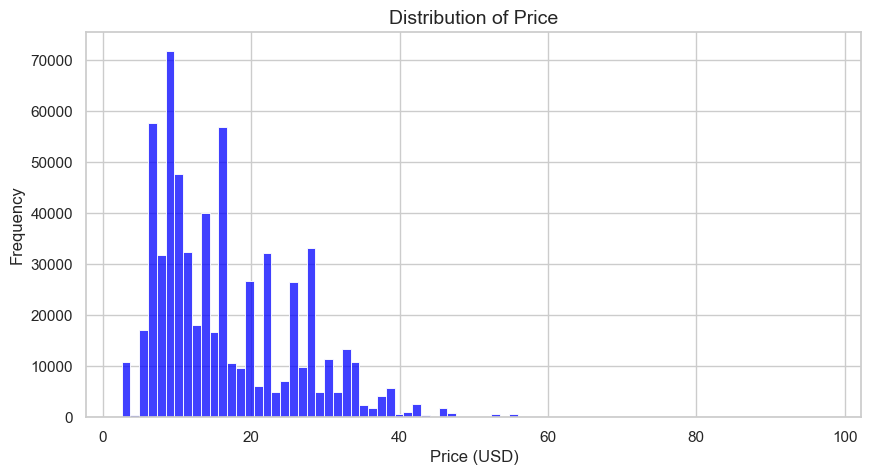

In [40]:
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=80, color='blue')
plt.title('Distribution of Price')
plt.xlabel('Price (USD)')
plt.ylabel('Frequency')
plt.show()

 **NOTE:** จากกราฟมีการเบ้ขวา

## Distance

In [44]:
quick_summary('distance')

  dtype     : float64
  non-null  : 637,976
  missing   : 0 (0.0%)
  min/max   : 0.02 / 7.86
  mean±std  : 2.189 ± 1.135
  median    : 2.16
  skewness  : 0.8168


### ดูการกระจายตัวของระยะทาง

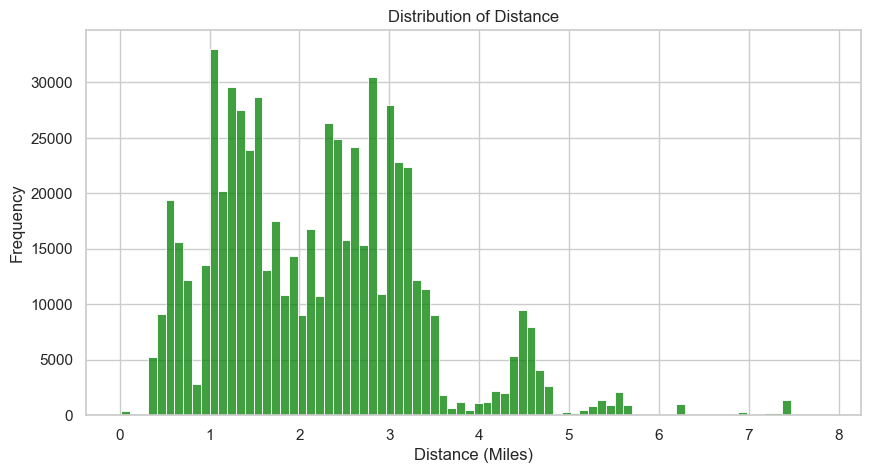

In [22]:
plt.figure(figsize=(10, 5))
sns.histplot(df['distance'], bins=80, color='green')
plt.title('Distribution of Distance')
plt.xlabel('Distance (Miles)')
plt.ylabel('Frequency')
plt.show()

 **NOTE:** จากกราฟมีการเบ้ขวาเล็กน้อย คาดว่า `distance` จะ correlate กับ `price` สูงมาก

## name

In [48]:
quick_summary('name')

  dtype     : int64
  non-null  : 637,976
  missing   : 0 (0.0%)
  min/max   : 0 / 11
  mean±std  : 5.536 ± 3.494
  median    : 6
  skewness  : -0.0229


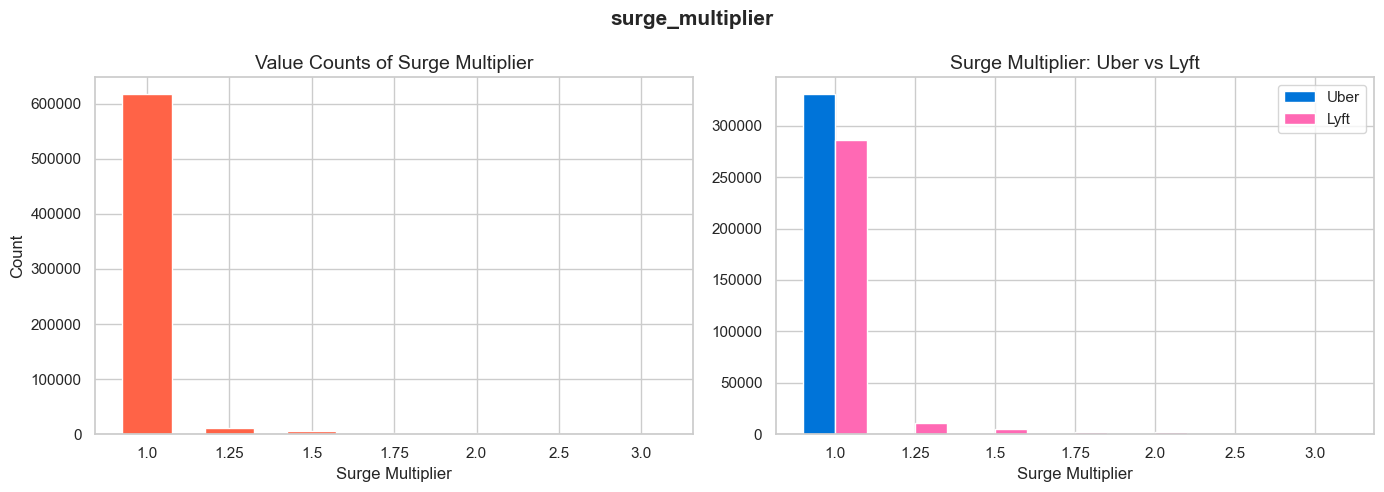

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

surge_counts = df['surge_multiplier'].value_counts().sort_index()
axes[0].bar(surge_counts.index.astype(str), surge_counts.values, color='tomato', width=0.6)
axes[0].set_title('Value Counts of Surge Multiplier')
axes[0].set_xlabel('Surge Multiplier')
axes[0].set_ylabel('Count')

# แยกดู Uber vs Lyft (ถ้ามี cab_type_Uber column)
if 'cab_type_Uber' in df.columns:
    uber_surge = df[df['cab_type_Uber'] == 1]['surge_multiplier'].value_counts().sort_index()
    lyft_surge = df[df['cab_type_Uber'] == 0]['surge_multiplier'].value_counts().sort_index()
    x = np.arange(len(surge_counts.index))
    axes[1].bar(x - 0.2, uber_surge.reindex(surge_counts.index, fill_value=0), 0.4, label='Uber', color='#0074D9')
    axes[1].bar(x + 0.2, lyft_surge.reindex(surge_counts.index, fill_value=0), 0.4, label='Lyft', color='#FF69B4')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(surge_counts.index.astype(str))
    axes[1].set_title('Surge Multiplier: Uber vs Lyft')
    axes[1].set_xlabel('Surge Multiplier')
    axes[1].legend()
else:
    sns.boxplot(y=df['surge_multiplier'], color='tomato', ax=axes[1])
    axes[1].set_title('Boxplot of Surge Multiplier')

plt.suptitle('surge_multiplier', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\tanad\AppData\Local\Temp\ipykernel_24180\3680367710.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cab_type_Uber', data=df, palette='Set2')


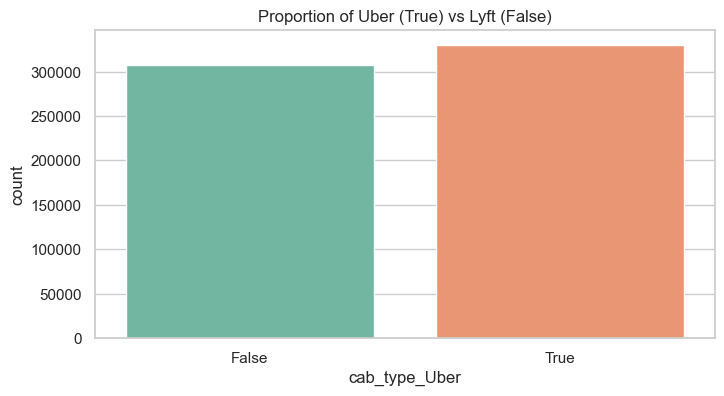

In [23]:
plt.figure(figsize=(8, 4))
sns.countplot(x='cab_type_Uber', data=df, palette='Set2')
plt.title('Proportion of Uber (True) vs Lyft (False)')
plt.show()

### ดูความหนาแน่นของการเรียกใช้บริการในแต่ละชั่วโมง

C:\Users\tanad\AppData\Local\Temp\ipykernel_24180\1854713672.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='hour', data=df, palette='viridis')


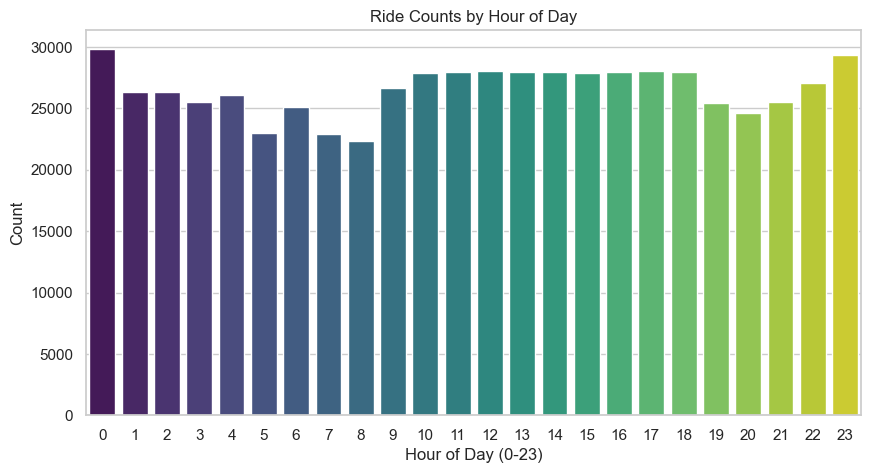

In [24]:
plt.figure(figsize=(10, 5))
sns.countplot(x='hour', data=df, palette='viridis')
plt.title('Ride Counts by Hour of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Count')
plt.show()